In [32]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("dataset_2191_sleep.csv")
df.head()

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645,3,5,3,3.3
1,1.000,6.6,4.5,42,3,1,3,8.3
2,3.385,44.5,14,60,1,1,1,12.5
3,0.920,5.7,?,25,5,2,3,16.5
4,2547.000,4603.0,69,624,3,5,4,3.9


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         62 non-null     object 
 3   gestation_time        62 non-null     object 
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           62 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 4.0+ KB


In [35]:
df["max_life_span"].replace("?" , "-1" , inplace=True)
df["gestation_time"].replace("?" , "-1" , inplace=True)

C:\Users\musta\AppData\Local\Temp\ipykernel_16936\3955811766.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["max_life_span"].replace("?" , "-1" , inplace=True)
C:\Users\musta\AppData\Local\Temp\ipykernel_16936\3955811766.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [36]:
df["max_life_span"] = pd.to_numeric(df["max_life_span"])
df["gestation_time"] = pd.to_numeric(df["gestation_time"])

In [37]:
df["max_life_span"].replace(-1 , df["max_life_span"].mean() , inplace=True)
df["gestation_time"].replace(-1 , df["gestation_time"].mean() , inplace=True)

C:\Users\musta\AppData\Local\Temp\ipykernel_16936\2046945294.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["max_life_span"].replace(-1 , df["max_life_span"].mean() , inplace=True)
C:\Users\musta\AppData\Local\Temp\ipykernel_16936\2046945294.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [38]:
df = df[df["total_sleep"] != "?"]

In [39]:
df["total_sleep"] = pd.to_numeric(df["total_sleep"])

In [40]:
df["total_sleep"].unique()

array([ 3.3,  8.3, 12.5, 16.5,  3.9,  9.8, 19.7,  6.2, 14.5,  9.7, 10.3,
        3.1,  8.4,  8.6, 10.7,  6.1, 18.1,  3.8, 14.4, 12. , 13. , 13.8,
        8.2,  2.9, 10.8,  9.1, 19.9,  8. , 10.6, 11.2, 13.2, 12.8, 19.4,
       17.4, 17. , 10.9, 13.7,  9.6,  6.6,  5.4,  2.6, 11. , 13.3, 15.8])

<Axes: >

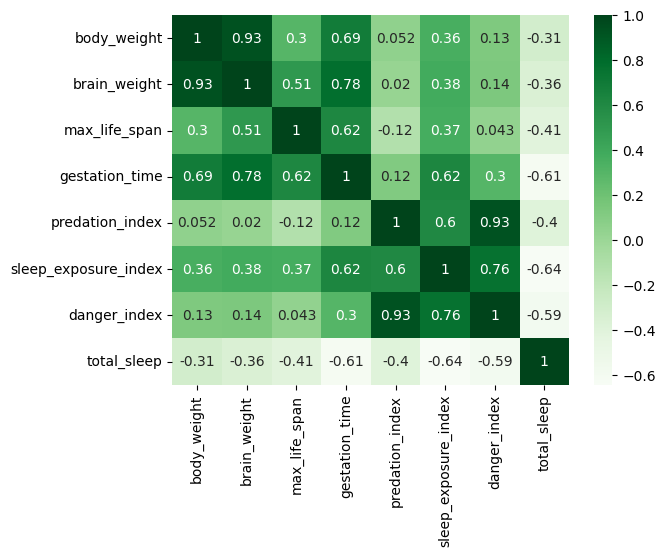

In [41]:
corr = df.corr()

sns.heatmap(corr , cmap="Greens" , annot=True)

In [45]:
x = df.iloc[: , :-1].values
y = df.iloc[: , -1].values

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x = scaler.fit_transform(x)

In [50]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=42)

In [52]:
!pip install xgboost

^C


   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 5.6 MB/s eta 0:00:23
   ---------------------------------------- 0.8/124.9 MB 2.8 MB/s eta 0:00:45
   ---------------------------------------- 1.0/124.9 MB 2.0 MB/s eta 0:01:02
    --------------------------------------- 1.6/124.9 MB 1.8 MB/s eta 0:01:08
    --------------------------------------- 1.6/124.9 MB 1.8 MB/s eta 0:01:08
    --------------------------------------- 2.1/124.9 MB 1.7 MB/s eta 0:01:14
    --------------------------------------- 2.4/124.9 MB 1.6 MB/s eta 0:01:19
    --------------------------------------- 2.4/124.9 MB 1.6 MB/s eta 0:01:19
    --------------------------------------- 2.6/124.9 MB 1.5 MB/s eta 0:01:22
    --------------------------------------- 2.9/124.9 MB 1.4 MB/s eta 0:01:28
   - --

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gruut 2.2.3 requires numpy<2.0.0,>=1.19.0, but you have numpy 2.0.2 which is incompatible.
tts 0.22.0 requires numpy==1.22.0; python_version <= "3.10", but you have numpy 2.0.2 which is incompatible.
tts 0.22.0 requires pandas<2.0,>=1.4, but you have pandas 1.1.4 which is incompatible.
tts 0.22.0 requires scikit-learn>=1.3.0, but you have scikit-learn 0.24.1 which is incompatible.


In [ ]:
from xgboost import XGBRegressor


model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.07,
    max_depth=7,
    random_state=42,
)

model.fit(
    x_train,
    y_train
)
